# Portfolio Optimization -- A Quadratic Programming Example

Suppose you are given a set of assets with the option to invest a total of \\$1 across all assets. You know the rate of return of each asset as well as the covariance of every pair of assets. How should you invest your \\$1?

First, let's graph the rate of return of each asset:

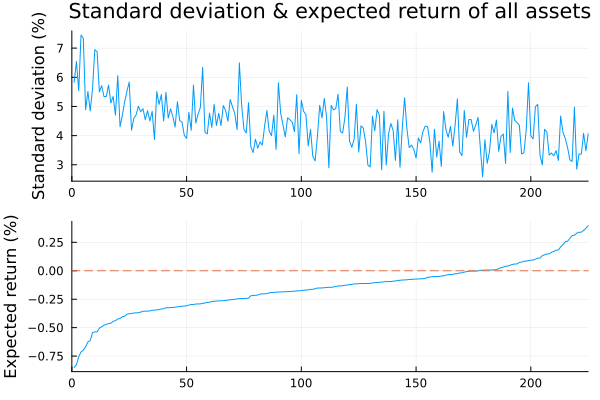

In [20]:
using DataFrames, CSV, LinearAlgebra

df = CSV.read("folio_mean.csv",DataFrame,header=false,delim=',')
r = 100 .*df # Expected return (in percent)
df2 = CSV.read("folio_cov.csv",DataFrame,header=false,delim=',')
Σ = 10000 .*Matrix(df2)# Expected variance (in percent squared)
ix = sortperm(r);   # sort the assets by expected return (this sorts the INDICES)
# plot the rates of return and standard deviation of each of the 225 assets 
using Plots

p1 = plot(sqrt.(diag(Σ))[ix],mc=:green,legend=false,xlims=(0,225),
    title="Standard deviation & expected return of all assets",ylabel="Standard deviation (%)")


p2 = plot(Array(r)[ix],xlims=(0,225),mc=:green,legend=false,ylabel="Expected return (%)")
plot!([0,225],[0,0],mc=:red,linestyle=:dash)

plot(p1, p2, layout=(2,1), )


We can also build a heatmap of the covariance of every pair of assets. Note the diagonal line showing covariance of each asset with itself.

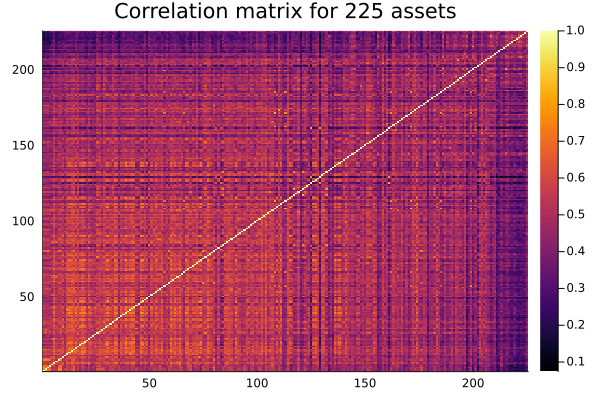

In [24]:
# plot correlation matrix (shows which assets are correlated with which other assets)
corr = diagm(diag(Σ).^(-1/2))*Σ*diagm(diag(Σ).^(-1/2))
heatmap(corr[ix,ix]);

title!("Correlation matrix for 225 assets")


And plot each asset in terms of rate of return and variance:

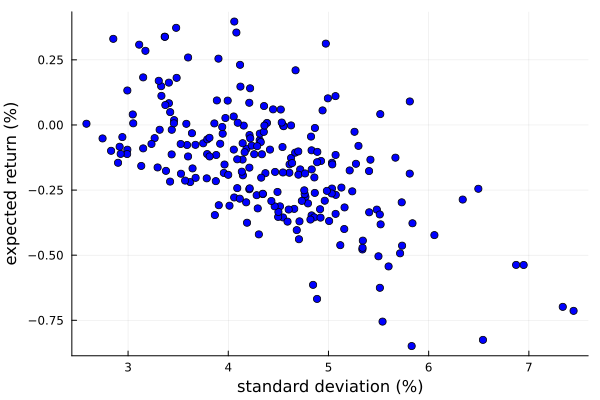

In [32]:
# plot each asset individually
scatter(sqrt.(diag(Σ)),Array(r),mc=:blue,legend=:false)
xlabel!("standard deviation (%)")
ylabel!("expected return (%)")


Finally, let's solve the problem:

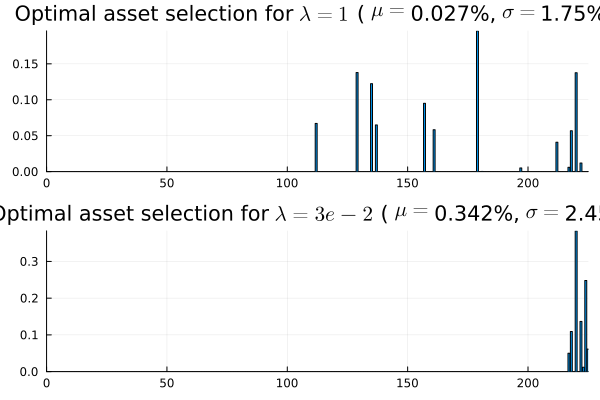

In [36]:
rr = Array(r) # for convenience, convert the data frame r into an Array (rr)

using JuMP, HiGHS
m = Model(HiGHS.Optimizer)

set_silent(m)

@variable(m, x[1:225] >= 0)
@constraint(m, sum(x) == 1)

# figure(figsize=(12,8))

# subplot(211)

λ = 1 # more weight on risk

@objective(m, Min, -dot(rr,x) + λ*dot(x,Σ*x) ) 
optimize!(m)
xsol = value.(x)
ix1 = findall(xsol .> 1e-4) # pull all xs with positive value
ret = dot(rr,xsol) # calculate rate of return
std = sqrt(dot(xsol,Σ*xsol)) # calculate covariance

p1 = bar(1:225,xsol[ix])
xlims!(0,225)
title!(string("Optimal asset selection for \$\\lambda=1\$"," ( \$\\mu=\$", round(ret,digits=3), "%, \$\\sigma=\$", round(std,digits=2), "% )"));


λ = 3e-2 # more weight on return

@objective(m, Min, -dot(rr,x) + λ*dot(x,Σ*x) )
optimize!(m)
xsol = value.(x)
ix2 = findall(xsol .> 1e-4) # pull all xs with positive value
ret = dot(rr,xsol) # calculate rate of return
std = sqrt(dot(xsol,Σ*xsol)) # calculate covariance

p2 = bar(1:225,xsol[ix])
xlims!(0,225)
title!(string("Optimal asset selection for \$\\lambda=3e-2\$"," ( \$\\mu=\$", round(ret,digits=3), "%, \$\\sigma=\$", round(std,digits=2), "% )"));

plot(p1,p2,layout=(2,1),legend=false)


In [37]:
# compute optimal tradeoff curve (this may take a few seconds)
N = 50
ret = zeros(N)
sdev = zeros(N)
lambda_values = 10 .^(range(-3,stop=4,length=N))

for (i,λ) in enumerate(lambda_values)
    @objective(m, Min, -dot(rr,x) + λ*dot(x,Σ*x) )
    optimize!(m)
    xsol = value.(x)
    ret[i] = dot(rr,xsol)
    sdev[i] = sqrt(dot(xsol,Σ*xsol))
end


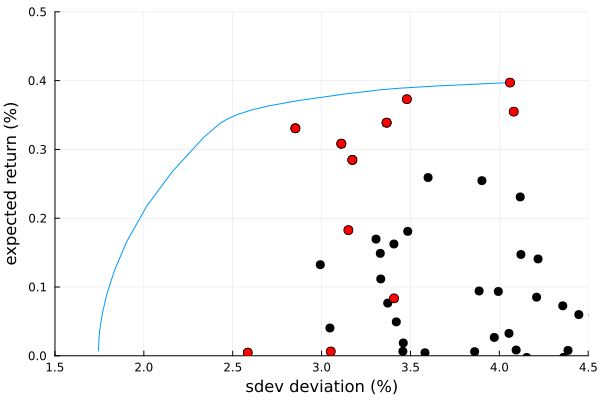

In [41]:
# plot tradeoff curve
plot(sdev,ret,xlims=(1.5,4.5),ylims=(0,.5),mc=:blue,legend=false)
scatter!(sqrt.(diag(Σ)), rr,mc=:black, markersize=5)
scatter!(sqrt.(diag(Σ))[ix1], rr[ix1], mc=:red, markersize=5)  # low-risk portfolio
scatter!(sqrt.(diag(Σ))[ix2], rr[ix2],mc=:red, markersize=5)  # at the "elbow" of the curve
xlabel!("sdev deviation (%)")
ylabel!("expected return (%)")
